In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Hyperparameter Tuning

## Setup

In [3]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / 'src'))

from hyperparameter_tuning_solution import (
    DATA_DIR, TABLE_DIR, FIG_DIR, save_table, save_bar,
    sonar_experiments, auto_insurance_experiments, nested_cv_experiment,
    hyperopt_mobile_experiment
)

import pandas as pd
import matplotlib.pyplot as plt

## Data sources

In [4]:
data_summary = pd.DataFrame([
    {'dataset': 'sonar.csv', 'task': 'classification', 'source': 'local file'},
    {'dataset': 'auto-insurance.csv', 'task': 'regression', 'source': 'local file'},
    {'dataset': 'mobile_price_data_train.csv', 'task': 'multiclass classification', 'source': 'local file'},
])
save_table(data_summary, '00_data_source_summary.csv')
data_summary

,dataset,task,source
0,sonar.csv,classification,local file
1,auto-insurance.csv,regression,local file
2,mobile_price_data_train.csv,multiclass classification,local file


## Sonar: Logistic Regression

In [5]:
sonar_results = sonar_experiments()
save_table(sonar_results, '01_sonar_grid_random_results.csv')
save_bar(sonar_results, 'experiment', 'best_score', 'Sonar: Grid Search vs Random Search', '01_sonar_grid_random_results.png')
sonar_results

,experiment,best_score,best_params,runtime_seconds
0,sonar_logistic_grid_search,0.774158,"{""model__C"": 0.01, ""model__penalty"": ""l2"", ""mo...",4.697372
1,sonar_logistic_random_search,0.781359,"{""model__C"": 0.024021761202431626, ""model__fit...",0.459732


## Auto Insurance: Ridge Regression

In [6]:
auto_results = auto_insurance_experiments()
save_table(auto_results, '02_auto_insurance_grid_random_results.csv')
plot_auto = auto_results.copy()
plot_auto['mae'] = -plot_auto['best_score']
save_bar(plot_auto, 'experiment', 'mae', 'Auto Insurance: MAE Comparison', '02_auto_insurance_grid_random_results.png')
auto_results

,experiment,best_score,best_params,runtime_seconds
0,auto_insurance_ridge_grid_search,-29.178255,"{""model__alpha"": 0.001, ""model__fit_intercept""...",0.605814
1,auto_insurance_ridge_random_search,-29.179458,"{""model__alpha"": 0.001033778201061742, ""model_...",0.309658


## Nested Cross-Validation

In [7]:
nested_results = nested_cv_experiment()
save_table(nested_results, '03_nested_cv_results.csv')
nested_results

,experiment,mean_accuracy,std_accuracy,fold_scores,runtime_seconds
0,sonar_random_forest_nested_cv,0.827526,0.10414,"[0.7857142857142857, 0.6428571428571429, 0.928...",4.289829


## Mobile Price: Hyperopt / TPE

100%|██████████| 40/40 [00:20<00:00,  1.95trial/s, best loss: -0.8879989434712073]


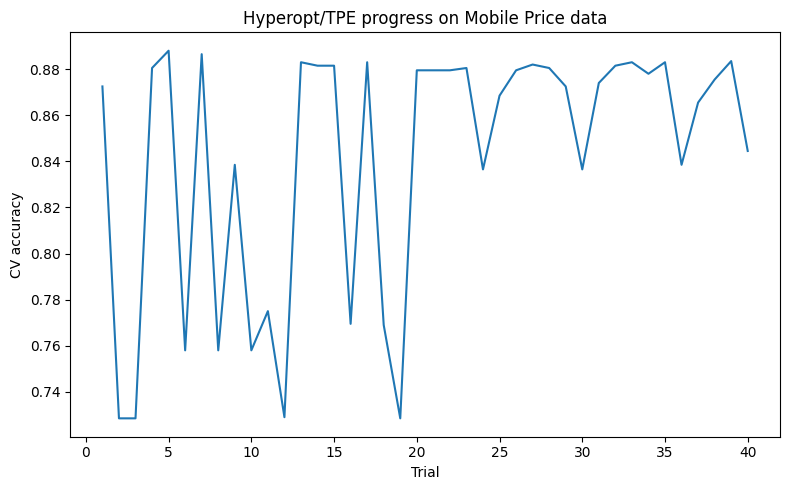

,experiment,best_score,best_params,runtime_seconds
0,mobile_price_random_forest_hyperopt_tpe,0.887999,"{""n_estimators"": 400, ""max_depth"": 12, ""criter...",20.550063


In [8]:
hyperopt_results, trials_df = hyperopt_mobile_experiment()
save_table(hyperopt_results, '04_mobile_hyperopt_results.csv')
if len(trials_df):
    save_table(trials_df, '05_hyperopt_trials.csv')
    plt.figure(figsize=(8, 5))
    plt.plot(trials_df['trial'], trials_df['accuracy'])
    plt.xlabel('Trial')
    plt.ylabel('CV accuracy')
    plt.title('Hyperopt/TPE progress on Mobile Price data')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '03_hyperopt_trials_progress.png', dpi=150)
    plt.show()
hyperopt_results

## Final summary

In [9]:
final = pd.concat([
    sonar_results,
    auto_results,
    nested_results.rename(columns={'mean_accuracy': 'best_score'}),
    hyperopt_results,
], ignore_index=True, sort=False)
save_table(final, '06_final_summary.csv')
final

,experiment,best_score,best_params,runtime_seconds,std_accuracy,fold_scores
0,sonar_logistic_grid_search,0.774158,"{""model__C"": 0.01, ""model__penalty"": ""l2"", ""mo...",4.697372,NaN,NaN
1,sonar_logistic_random_search,0.781359,"{""model__C"": 0.024021761202431626, ""model__fit...",0.459732,NaN,NaN
2,auto_insurance_ridge_grid_search,-29.178255,"{""model__alpha"": 0.001, ""model__fit_intercept""...",0.605814,NaN,NaN
3,auto_insurance_ridge_random_search,-29.179458,"{""model__alpha"": 0.001033778201061742, ""model_...",0.309658,NaN,NaN
4,sonar_random_forest_nested_cv,0.827526,NaN,4.289829,0.10414,"[0.7857142857142857, 0.6428571428571429, 0.928..."
5,mobile_price_random_forest_hyperopt_tpe,0.887999,"{""n_estimators"": 400, ""max_depth"": 12, ""criter...",20.550063,NaN,NaN
